# Part 1

In [1]:
import pandas as pd
import numpy as np

# 1) Load the given dataset
df = pd.read_csv(r"D:\Ali\Project Portfolio\ML Projects\Naive Bayes\ML Project - Naive Bayes Loan Status Classification.txt")
df

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default Status
0,1,2.0,24,3913.0,312.0,689.0,NaN,NaN,NaN,NaN,689.0,NaN,NaN,NaN,NaN,Default
1,2,12.0,26,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,NaN,1.0,1.0,1.0,NaN,2.0,Default
2,3,9.0,34,29239.0,1427.0,13559.0,14331.0,14948.0,15549.0,1518.0,15.0,1.0,1.0,1.0,5.0,Not Default
3,4,5.0,37,4699.0,48233.0,49291.0,28314.0,28959.0,29547.0,2.0,219.0,12.0,11.0,169.0,1.0,Not Default
4,5,5.0,57,8617.0,567.0,35835.0,294.0,19146.0,19131.0,2.0,36681.0,1.0,9.0,689.0,679.0,Not Default
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,22.0,39,188948.0,192815.0,28365.0,884.0,31237.0,1598.0,85.0,2.0,53.0,347.0,5.0,1.0,Not Default
29996,29997,15.0,43,1683.0,1828.0,352.0,8979.0,519.0,NaN,1837.0,3526.0,8998.0,129.0,NaN,NaN,Not Default
29997,29998,3.0,37,3565.0,3356.0,2758.0,2878.0,2582.0,19357.0,NaN,NaN,22.0,42.0,2.0,31.0,Default
29998,29999,8.0,41,-1645.0,78379.0,7634.0,52774.0,11855.0,48944.0,859.0,349.0,1178.0,1926.0,52964.0,184.0,Default


In [2]:
# 2) Check the null values
print("--- Null Values ---")
print(df.isnull().sum())

--- Null Values ---
ID                   0
LIMIT_BAL            0
AGE                  0
BILL_AMT1         2008
BILL_AMT2         2506
BILL_AMT3         2870
BILL_AMT4         3195
BILL_AMT5         3506
BILL_AMT6         4020
PAY_AMT1          5249
PAY_AMT2          5396
PAY_AMT3          5968
PAY_AMT4          6408
PAY_AMT5          6703
PAY_AMT6          7173
Default Status       0
dtype: int64


In [3]:
# 3) Print the column names
print("\n--- Column Names ---")
print(df.columns.tolist())


--- Column Names ---
['ID', 'LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default Status']


In [4]:
# 4) Create list for all the columns which have null values
null_cols = [col for col in df.columns if df[col].isnull().sum() > 0]
print("\nColumns with null values:", null_cols)


Columns with null values: ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [5]:
# 5) Fill all the null values with mean using for loops
for col in null_cols:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].mean(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3792\3988228489.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [6]:
# 6) Get data information
print("\n--- Data Info ---")
df.info()


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              30000 non-null  int64  
 1   LIMIT_BAL       30000 non-null  float64
 2   AGE             30000 non-null  int64  
 3   BILL_AMT1       30000 non-null  float64
 4   BILL_AMT2       30000 non-null  float64
 5   BILL_AMT3       30000 non-null  float64
 6   BILL_AMT4       30000 non-null  float64
 7   BILL_AMT5       30000 non-null  float64
 8   BILL_AMT6       30000 non-null  float64
 9   PAY_AMT1        30000 non-null  float64
 10  PAY_AMT2        30000 non-null  float64
 11  PAY_AMT3        30000 non-null  float64
 12  PAY_AMT4        30000 non-null  float64
 13  PAY_AMT5        30000 non-null  float64
 14  PAY_AMT6        30000 non-null  float64
 15  Default Status  30000 non-null  object 
dtypes: float64(13), int64(2), object(1)
memory usage: 3.7+ MB

In [7]:
# 7) Describe dataset
print("\n--- Dataset Description ---")
print(df.describe())


--- Dataset Description ---
                 ID     LIMIT_BAL           AGE      BILL_AMT1      BILL_AMT2  \
count  30000.000000  30000.000000  30000.000000   30000.000000   30000.000000   
mean   10666.660700     14.648867     32.427900   33989.494570   33938.750418   
std     9698.091793    189.496507     12.718991   59472.881131   58305.224138   
min        1.000000      1.000000      3.000000 -154973.000000  -69777.000000   
25%     1850.500000      4.000000     26.000000    1788.000000    1847.750000   
50%     7483.500000      9.000000     33.000000   11569.000000   12637.000000   
75%    18746.250000     21.000000     41.000000   33989.494570   33938.750418   
max    29999.000000  32768.000000     79.000000  964511.000000  983931.000000   

           BILL_AMT3     BILL_AMT4      BILL_AMT5      BILL_AMT6  \
count   30000.000000   30000.00000   30000.000000   30000.000000   
mean    32617.867011   30709.50416   29015.123424   28526.276559   
std     55777.906879   51825.29715   

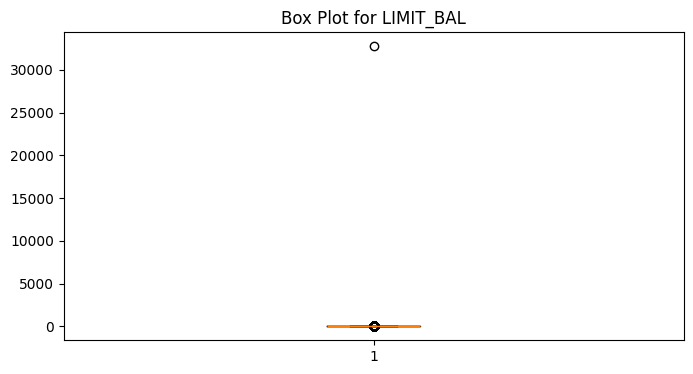

In [8]:
import matplotlib.pyplot as plt

# 8) Display box plot for LIMIT_BAL
plt.figure(figsize=(8, 4))
plt.boxplot(df['LIMIT_BAL'])
plt.title('Box Plot for LIMIT_BAL')
plt.show()

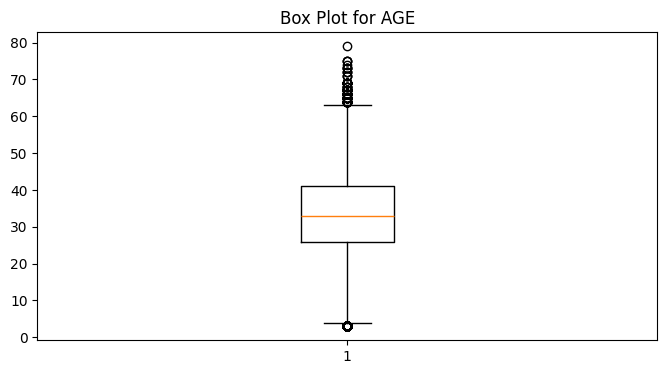

In [9]:
# 9) Display box plot for AGE
plt.figure(figsize=(8, 4))
plt.boxplot(df['AGE'])
plt.title('Box Plot for AGE')
plt.show()

In [10]:
# 10) Drop all the null values (Ensuring no nulls remain)
df.dropna(inplace=True)

In [11]:
from sklearn.preprocessing import LabelEncoder

# 11) Perform encoding on Default Status
le = LabelEncoder()
df['Default Status'] = le.fit_transform(df['Default Status'])

# Part 2

In [12]:
# 1) Create a features and target dataset
X = df.drop('Default Status', axis=1)
y = df['Default Status']

In [13]:
from sklearn.model_selection import train_test_split

# 2) Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [14]:
from sklearn.naive_bayes import GaussianNB

# 3) Fit the Gaussian naive bayes classifier
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [15]:
# 4) Print the training score
print(f"\nTraining Score: {model.score(X_train, y_train)*100:.4f}")


Training Score: 76.2542


In [16]:
# 5) Print the testing score
print(f"Testing Score: {model.score(X_test, y_test)*100:.4f}")

Testing Score: 75.4833


In [17]:
# Predictions for metrics
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# 6) Find the accuracy score
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)*100:.4f}")

Accuracy Score: 75.4833


In [19]:
# 7) Find the precision score
print(f"Precision Score: {precision_score(y_test, y_pred, average='weighted')*100:.4f}")

Precision Score: 62.1080


In [20]:
# 8) Find the recall score
print(f"Recall Score: {recall_score(y_test, y_pred, average='weighted')*100:.4f}")

Recall Score: 75.4833


In [21]:
# 9) Find the Confusion matrix
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))


--- Confusion Matrix ---
[[  16 1359]
 [ 112 4513]]


In [22]:
# 10) Find the Classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.12      0.01      0.02      1375
           1       0.77      0.98      0.86      4625

    accuracy                           0.75      6000
   macro avg       0.45      0.49      0.44      6000
weighted avg       0.62      0.75      0.67      6000

